EDA


In [163]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [164]:
url = 'https://raw.githubusercontent.com/manasacharyagit/movie-review-sentiment/refs/heads/master/moviereviews.csv'
df = pd.read_csv(url, lineterminator='\n')

In [165]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


In [166]:
#Checking for any null values
df.isnull().sum()

label      0
review    35
dtype: int64

In [167]:
# There are 35 null values so lets just drop them
df = df.dropna()

In [168]:
df.isnull().sum()

label     0
review    0
dtype: int64

In [169]:
# We have checked for null reviews now let's check if there's any review that is just empty string = "" or " "
df['review'].str.isspace().sum() # isspace return completely blank strings

# This shows there are 27 reviews which are just blank strings

np.int64(27)

In [170]:
# Now we want to have only those reviews which are not blank so

df = df[~df['review'].str.isspace()] # ~ sing does the opposite

In [171]:
df['review'].str.isspace().sum()

np.int64(0)

Getting top 20 words per label type (neg or pos)

In [172]:
# For this we will use CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer
count_vect = CountVectorizer(stop_words='english')

matrixneg = count_vect.fit_transform(df[df['label']=='neg']['review'])
freqs = zip(count_vect.get_feature_names_out(), matrixneg.sum(axis=0).tolist()[0])

print("Negative words ->", sorted(freqs, key=lambda x: -x[1])[:20])

matrixpos = count_vect.fit_transform(df[df['label']=='pos']['review'])
freqs = zip(count_vect.get_feature_names_out(), matrixpos.sum(axis=0).tolist()[0])

print("Positive words ->", sorted(freqs, key=lambda x: -x[1])[:20])

Negative words -> [('film', 4063), ('movie', 3131), ('like', 1808), ('just', 1480), ('time', 1127), ('good', 1117), ('bad', 997), ('character', 926), ('story', 908), ('plot', 888), ('characters', 838), ('make', 813), ('really', 743), ('way', 734), ('little', 696), ('don', 683), ('does', 666), ('doesn', 648), ('action', 635), ('scene', 634)]
Positive words -> [('film', 5002), ('movie', 2389), ('like', 1721), ('just', 1273), ('story', 1199), ('good', 1193), ('time', 1175), ('character', 1037), ('life', 1032), ('characters', 957), ('way', 864), ('films', 851), ('does', 828), ('best', 788), ('people', 769), ('make', 764), ('little', 751), ('really', 731), ('man', 728), ('new', 702)]


Train Test Split

In [173]:
X = df['review']
y = df['label']

In [174]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)


Training the model - Creating a pipeline that will create a TF-IDF Vector out of the raw text data and fit
the model. Then fit that pipeline on the training data

In [175]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB


In [176]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1, max_df=0.97)),
    ('nb', MultinomialNB())
])

In [177]:
pipe.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('nb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


Classfication report and confusion matrix

In [178]:
from sklearn.metrics import classification_report, confusion_matrix

In [179]:
preds = pipe.predict(X_test)

In [180]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

         neg       0.83      0.85      0.84       191
         pos       0.85      0.83      0.84       197

    accuracy                           0.84       388
   macro avg       0.84      0.84      0.84       388
weighted avg       0.84      0.84      0.84       388



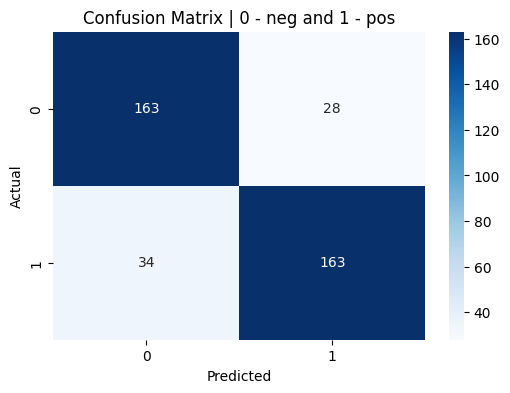

In [181]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix | 0 - neg and 1 - pos")
plt.show()

Now we have our model with 86% accuracy, lets test it on dummy data

In [ ]:
review1= ["Pathetic movie. The movie is far away from the actual story of Ramayana. "
"The director seems to be more influenced by Harry Potter, game of thrones, "
"planet of apes rather than depict the actual story of Ramayana. "
"Ramayana the great epic have been brought down to a fantasy movie. What were the creators thinking to tell the audience. Disappointment."]
print("Prediction:", pipe.predict(review1)[0])


review2 = ["This movie is just... wow! I don't think I have ever felt like this watching a movie!Its like a blend of being sad but also scared! I read that Christopher Nolan said it kind of had themes of horror, and watching the movie i think I knew what he meant! Very few movies can make you feel quite like this one can! Nolan once again shows he is an expertly craftsman in filmmaking! This stands as perhaps one of his more humble movies but also one of his greatest! Reminds me of his earlier movies! The cast is also AMAZING with Cillian Murphy delivering the performance of his carrer as Oppenheimer, esentially becoming him, and pretty much securing himself an Oscar nomination for best lead actor! Robert Downey Junior also gives one of his best performances, reminding us all that despite 10 years as Iron man, he can still act! The soundtrack, sound and editing is also masterfull and further creates a cinematic experience like no other! Overall an esential viewing experience about historic events that still remains very relevant to this day! One of my favorite Nolan movies!"]

prediction = pipe.predict(review2)
print("Prediction:", prediction[0])



Prediction: neg
Prediction: pos
